# Human in the Loop

In [ ]:
# 워크플로 실행중 사람의 개입이 필요한 경우도 있다.
# ex) 중간결과에 대해 사람의 판단을 요구
# ex) 사람이 힌트를 준다든가..

# 이러한 것을 Human-In-The-Loop 라 한다.

# Human-In-The-Loop 는 보통 다음과 같은 4단계로 구성
# 1. 중단점(Breakpoint) : AI가 인간의 개입이 필요한 지점을 인식
# 2. 컨텍스트 제공: 인간이 올바른 결정을 내릴 수 있도록 충분한 정보 제공
# 3. 피드백 수집 : 구조화된 방식으로 인간의 입력 수집
# 4. 재개(Resume) : 인간의 결정에 따라 워크플로 계속 진행

# import

In [1]:
from dotenv import load_dotenv
print(load_dotenv())

from typing import Literal
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from pydantic import BaseModel, Field
from IPython.display import Image, display

True


# 상태 정의

In [2]:
class AgentState(BaseModel):
    user_message: str = Field(default="", description="사용자 입력 작업")
    task_details: str = Field(default="", description="작업 상세 정보")
    response: str = Field(default="", description="응답 결과")    

# 노드 함수 정의

In [3]:
def get_llm_response_node(state: AgentState, llm):
    """LLM 과 상호 작용하여 응답을 생성하거나, 추가 정보를 요청하는 노드"""

    details = state.task_details

    if details:
        print(f"\n상세 정보를 바탕으로 작업 실행: '{details}'")
        prompt = f"다음 요청에 따라 보고서를 작성해주세요: {details}"     
    else:
        task = state.user_message
        print(f"\n작업 실행: `{task}` 작업을 수행합니다...")

        # ↓ 물음표로 끝내도록 명시적으로 지시
        #  후속 조건부 분기에서 LLM 이 추가 정보를 요청하는지, 아니면 최종 결과를 생성했는지를 명확하게 구분
        prompt = f"""
            '{task}' 작업을 수행하려고 합니다. 어떤 종류의 보고서가 필요한지, 구체적인 주제는 무엇인지 질문해주세요. 
            추가 정보가 필요하면, 반드시 응답의 마지막을 물음표('?')로 끝내주세요.
        """

    response = llm.invoke(prompt).content    

    print("--- LLM 응답 ---")
    print(response)
    print("-----------------")

    return {"response": response, "task_details": ""}

# 사람의 입력을 받는 노드

In [4]:
# 워크플로 실행을 일시 중지 .  사용자 입력 대기
# LLM 이 요청한 추가정보를 사용자로부터 수집 하여 -> task_details 필드에 저장.
# 이 노드는 AI 와 인간과의 대화형 상호작용을 가능하게 하는 역할.

In [5]:
def get_task_details_node(state: AgentState) -> AgentState:
    """LLM의 질문에 대한 사용자 답변을 입력받는 노드"""
    print("\nLLM의 질문에 답변해주세요")
    user_input = input("답변: ")
    return {"task_details": user_input}

# 조건부 분기 노드

In [6]:
# LLM 응답 패턴 분석하여 다음 경로 결정
# "? 물음표" 로 끝나면 get_details 노드로 분기
#            그렇지 앟으면 워크플로 종료

In [7]:
def check_llm_response(state: AgentState) -> Literal["get_details", "end"]:
    print("LLM 응답 분석 중...")
    if state.response.strip().endswith("?"):
        print("LLM 이 추가 정보를 요청했습니다.  사용자 입력을 받겠습니다")
        return "get_details"

    print("최종보고서가 생성되었습니다. 워크플로우를 종료합니다")
    return "end"

# 워크 플로 생성

In [8]:
def create_graph():

    llm = init_chat_model("gpt-4o", model_provider="openai")

    def get_llm_response_with_llm(state):
        return get_llm_response_node(state, llm)
    
    workflow = StateGraph(AgentState)
    workflow.add_node("get_llm_response", get_llm_response_with_llm)
    workflow.add_node("get_details", get_task_details_node)

    workflow.add_edge(START, "get_llm_response")
    workflow.add_conditional_edges(
        "get_llm_response",
        check_llm_response,
        {
            "get_details": "get_details",
            "end": END,
        },
    )
    workflow.add_edge("get_details", "get_llm_response")

    return workflow.compile()

# 실행

In [11]:
app = create_graph()

final_state = app.invoke(AgentState(user_message="블로그 글 작성"))
print("\n---워크플로 종료 ---")
print("최종응답:")
print(final_state["response"])


작업 실행: `블로그 글 작성` 작업을 수행합니다...
--- LLM 응답 ---
블로그 글 작성을 위한 작업의 방향성을 잡기 위해, 어떤 종류의 블로그를 운영하고 계신지 알려주실 수 있을까요? 또한, 특정 주제나 업종에 관련된 글을 원하시는지, 혹은 대중적이고 일반적인 주제를 원하시는지? 타겟 독자가 누구인지도 함께 말씀해 주시면 더욱 도움이 될 것 같습니다. 보고서에 포함되어야 할 특별한 자료나 참고할 만한 자료가 있는지도 궁금합니다?
-----------------
LLM 응답 분석 중...
LLM 이 추가 정보를 요청했습니다.  사용자 입력을 받겠습니다

LLM의 질문에 답변해주세요


답변:  20대를 대상으로 글 작성



상세 정보를 바탕으로 작업 실행: '20대를 대상으로 글 작성'
--- LLM 응답 ---
물론입니다! 20대를 대상으로 한 보고서의 주제는 여러 가지가 가능하지만, 여기서는 "20대의 경제적 도전과 기회"라는 주제로 작성해보겠습니다.

---

### 20대를 위한 경제적 도전과 기회

#### 서론
20대는 인생의 중요한 전환기입니다. 대학교 졸업, 첫 직장, 자립 생활 시작 등 인생의 여러 변곡점들이 이 시기에 결정됩니다. 이러한 변화들은 20대 청년들에게 경제적 도전과 동시에 무수한 기회를 제공합니다. 이 보고서에서는 20대가 흔히 맞닥뜨리는 경제적 과제와 이를 극복하기 위한 전략, 그리고 20대가 활용할 수 있는 기회들에 대해 살펴보겠습니다.

#### 20대의 경제적 도전

1. **학자금 대출 부담**
   많은 20대가 대학 학비를 충당하기 위해 학자금 대출을 이용합니다. 졸업 후 갚아야 할 부채는 커리어 초기에 큰 부담으로 작용할 수 있습니다.

2. **주거비 문제**
   대부분의 20대가 독립적인 거주를 원하지만, 높은 임대료와 주거비는 큰 장벽입니다. 특히 대도시에서는 이 문제가 더욱 심각할 수 있습니다.

3. **직업 안정성 부족**
   첫 직장은 안정적이지 않을 수 있으며, 직업 시장의 빠른 변화는 추가적인 도전 과제를 던집니다. 이는 경제적 불확실성을 증가시킬 수 있습니다.

4. **금융 교육 부족**
   많은 젊은이들이 재무 관리, 투자, 저축에 대한 교육을 충분히 받지 못한 채 경제 생활을 시작합니다. 이로 인해 초기 자산 형성이 어려울 수 있습니다.

#### 극복을 위한 전략

1. **재무 계획 수립**
   예산을 관리하고 지출을 모니터링하는 습관을 들이면 경제적 스트레스를 줄일 수 있습니다. 장기적인 저축 계획과 함께 투자 기초를 배우는 것도 중요합니다.

2. **정부 및 지역 사회 지원 활용**
   각종 장학금, 주거 지원 프로그램, 청년 창업 지원 정책 등을 잘 활용하면 경제적 부담을 줄일 수 있습니다.

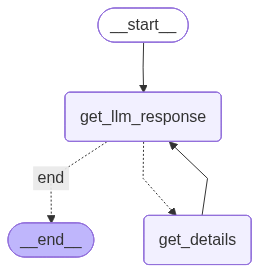

In [10]:
Image(app.get_graph().draw_mermaid_png())